<h1 align="center"><b>Performance Analysis in Formula One</b></h1>

Lorem ipsum dolor sit amet, consectetur adipiscing elit. Donec risus odio, blandit et sapien in, pharetra convallis nulla. Cras facilisis, arcu vitae sollicitudin ornare, velit arcu lacinia quam, vitae consequat mi felis quis dolor. Donec tincidunt commodo lectus nec porta. Pellentesque eu felis erat. Cras ac porta turpis. Quisque tincidunt auctor mattis. Maecenas convallis orci mauris, tempor rutrum nibh sodales sed. Curabitur in enim a leo tempus rutrum id vitae mauris. Quisque ullamcorper posuere fringilla. Morbi et ante lacinia justo dignissim placerat.

In [ ]:
# Install Required Packages
!pip install fastf1
!pip install pandas matplotlib seaborn plotly


import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import fastf1
import fastf1.plotting
from fastf1.core import Laps

# Enable Cache
os.makedirs('cache', exist_ok=True)
fastf1.Cache.enable_cache('cache')

---


<h1 align="center"><b>Graph 1: Tire Compound and Degradation</b></h1>



---

In [ ]:
# Imports Libaries
import os
import fastf1
import fastf1.plotting
import pandas as pd
import plotly.graph_objects as go

# Enable Cache
os.makedirs("cache", exist_ok=True)
fastf1.Cache.enable_cache("cache")


# Load Session
session = fastf1.get_session(2025, "Monaco", "R")
session.load()
laps = session.laps


# Stint Data
stints = (
    laps.groupby(["Driver", "Stint", "Compound"])
        .agg(LapStart=("LapNumber", "min"),
             LapEnd=("LapNumber", "max"))
        .reset_index()
)

stints["StintLength"] = stints["LapEnd"] - stints["LapStart"] + 1
df = stints.copy()


# Driver Order
results = session.results.sort_values("Position")
driver_order = results["Abbreviation"].tolist()

df["Driver"] = pd.Categorical(
    df["Driver"],
    categories=driver_order,
    ordered=True
)

df = df.sort_values(["Driver", "Stint"])


# Tire Colors
TIRE_COLORS = {
    "SOFT": "#F6CE71",
    "MEDIUM": "#FF6500",
    "HARD": "#C40C0C",
}


# Team Colors
team_colors = {
    row["Abbreviation"]:
    fastf1.plotting.get_team_color(row["TeamName"], session=session)
    for _, row in session.results.iterrows()
}


# Graph
fig = go.Figure()
added_to_legend = set()

for _, row in df.iterrows():

    compound = row["Compound"]

    fig.add_trace(
        go.Bar(
            x=[row["StintLength"]],
            y=[row["Driver"]],
            base=row["LapStart"],
            orientation="h",
            width=0.6,

            marker=dict(
                color=TIRE_COLORS.get(compound),
                opacity=0.92,
                line=dict(width=0)
            ),

            # ✅ FIXED HOVER
            customdata=[[
                compound,
                row["Stint"],
                row["LapStart"],
                row["LapEnd"]
            ]],

            hovertemplate="<b>%{y}</b><br>"
                          "Compound: %{customdata[0]}<br>"
                          "Stint: %{customdata[1]}<br>"
                          "Lap Range: %{customdata[2]} - %{customdata[3]}"
                          "<extra></extra>",

            name=compound,
            showlegend=compound not in added_to_legend
        )
    )

    added_to_legend.add(compound)


# Layout Styling
fig.update_layout(

    title=dict(
        text="2025 Monaco Grand Prix Driver Tire Compound",
        x=0.02,
        font=dict(size=30)
    ),

    barmode="overlay",
    plot_bgcolor="#1c1c1c",
    paper_bgcolor="#1c1c1c",

    font=dict(color="#F1E9E9", family="Courier New"),

    xaxis=dict(
        title=dict(text="Lap Number", font=dict(size=26)),
        tickfont=dict(size=16),
        showgrid=True,
        gridcolor="rgba(255,255,255,0.05)",
        zeroline=False,
        tickmode="linear",
        dtick=5
    ),

    yaxis=dict(
        title=dict(text="Driver", font=dict(size=26)),
        tickfont=dict(size=16),
        showgrid=False,
        autorange="reversed",
        tickmode="array",
        tickvals=driver_order,
        ticktext=[
            f"<span style='color:{team_colors[d]}'>{d}</span>"
            for d in driver_order
        ]
    ),

    legend=dict(
        title="Tire Compound:",
        title_font=dict(size=18),
        font=dict(size=15),
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1,
        bgcolor="rgba(0,0,0,0)"
    ),

    margin=dict(l=140, r=40, t=100, b=80),
    hovermode="closest"
)


# Hover Stying
fig.update_traces(
    hoverlabel=dict(
        bgcolor="#2a2a2a",
        font_size=14,
        font_family="Courier New"
    )
)

fig.show()

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.7.0]
INFO:fastf1.fastf1.core:Loading data for Monaco Grand Prix - Race [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_dat

Lorem Ipsum is simply dummy text of the printing and typesetting industry. Lorem Ipsum has been the industry's standard dummy text ever since the 1500s, when an unknown printer took a galley of type and scrambled it to make a type specimen book. It has survived not only five centuries, but also the leap into electronic typesetting, remaining essentially unchanged. It was popularised in the 1960s with the release of Letraset sheets containing Lorem Ipsum passages, and more recently with desktop publishing software like Aldus PageMaker including versions of Lorem Ipsum.

---


<h1 align="center"><b>Graph 2: Pit Stop Efficiency</b></h1>



---

In [ ]:
# Graph Code

Lorem Ipsum is simply dummy text of the printing and typesetting industry. Lorem Ipsum has been the industry's standard dummy text ever since the 1500s, when an unknown printer took a galley of type and scrambled it to make a type specimen book. It has survived not only five centuries, but also the leap into electronic typesetting, remaining essentially unchanged. It was popularised in the 1960s with the release of Letraset sheets containing Lorem Ipsum passages, and more recently with desktop publishing software like Aldus PageMaker including versions of Lorem Ipsum.

---


<h1 align="center"><b>Graph 3: Aerodynamic Performance and Downforce</b></h1>



---

In [ ]:
# Graph Code

Lorem Ipsum is simply dummy text of the printing and typesetting industry. Lorem Ipsum has been the industry's standard dummy text ever since the 1500s, when an unknown printer took a galley of type and scrambled it to make a type specimen book. It has survived not only five centuries, but also the leap into electronic typesetting, remaining essentially unchanged. It was popularised in the 1960s with the release of Letraset sheets containing Lorem Ipsum passages, and more recently with desktop publishing software like Aldus PageMaker including versions of Lorem Ipsum.

---


<h1 align="center"><b>Graph 4: DRS Speed Gains</b></h1>



---

In [ ]:
# Graph Code

Lorem Ipsum is simply dummy text of the printing and typesetting industry. Lorem Ipsum has been the industry's standard dummy text ever since the 1500s, when an unknown printer took a galley of type and scrambled it to make a type specimen book. It has survived not only five centuries, but also the leap into electronic typesetting, remaining essentially unchanged. It was popularised in the 1960s with the release of Letraset sheets containing Lorem Ipsum passages, and more recently with desktop publishing software like Aldus PageMaker including versions of Lorem Ipsum.

---


<h1 align="center"><b>Graph 5: Car Performances in Corners and Straights</b></h1>



---

In [ ]:
# Graph Code

Lorem Ipsum is simply dummy text of the printing and typesetting industry. Lorem Ipsum has been the industry's standard dummy text ever since the 1500s, when an unknown printer took a galley of type and scrambled it to make a type specimen book. It has survived not only five centuries, but also the leap into electronic typesetting, remaining essentially unchanged. It was popularised in the 1960s with the release of Letraset sheets containing Lorem Ipsum passages, and more recently with desktop publishing software like Aldus PageMaker including versions of Lorem Ipsum.

---


<h1 align="center"><b>Graph 6: Individual Driver Performances</b></h1>



---

core           INFO 	Loading data for Japanese Grand Prix - Race [v3.7.0]
INFO:fastf1.fastf1.core:Loading data for Japanese Grand Prix - Race [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status

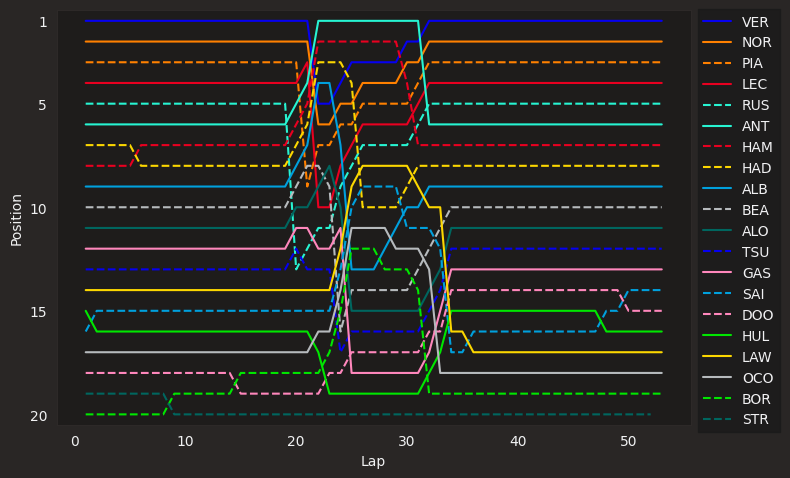

In [ ]:
fastf1.plotting.setup_mpl(mpl_timedelta_support=False, color_scheme='fastf1')

session = fastf1.get_session(2025, 3, 'R')
session.load(telemetry=False, weather=False)

fig, ax = plt.subplots(figsize=(8.0, 4.9))

for drv in session.drivers:
    drv_laps = session.laps.pick_drivers(drv)

    abb = drv_laps['Driver'].iloc[0]
    style = fastf1.plotting.get_driver_style(identifier=abb,
                                             style=['color', 'linestyle'],
                                             session=session)

    ax.plot(drv_laps['LapNumber'], drv_laps['Position'],
            label=abb, **style)

ax.set_ylim([20.5, 0.5])
ax.set_yticks([1, 5, 10, 15, 20])
ax.set_xlabel('Lap')
ax.set_ylabel('Position')

ax.grid(False)
ax.legend(bbox_to_anchor=(1.0, 1.02))
plt.tight_layout()

plt.show()